In [ ]:
# VAE pour prédiction de Time Series S&P 500

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.losses import mse
import tensorflow as tf

# 1. Chargement des données
sp500 = yf.download('^GSPC', start='2010-01-01', end='2025-01-01')
data = sp500[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()

# 2. Normalisation
data_values = data.values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_values)

# 3. Construction des séquences
past_window = 30
future_window = 10
X, y = [], []
for i in range(len(data_scaled) - past_window - future_window):
    X.append(data_scaled[i:i+past_window])
    y.append(data_scaled[i+past_window:i+past_window+future_window])
X = np.array(X)
y = np.array(y)

# 4. Définition du VAE
latent_dim = 16
input_shape = X.shape[1:]

# Encodeur
encoder_inputs = Input(shape=input_shape)
x = layers.LSTM(64, return_sequences=False)(encoder_inputs)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Décodeur
decoder_inputs = Input(shape=(latent_dim,))
x = layers.RepeatVector(future_window)(decoder_inputs)
x = layers.LSTM(64, return_sequences=True)(x)
decoder_outputs = layers.TimeDistributed(layers.Dense(input_shape[1]))(x)
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

# VAE Model
outputs = decoder(encoder(encoder_inputs)[2])
vae = Model(encoder_inputs, outputs, name='vae')

# Loss
reconstruction_loss = mse(y, outputs)
reconstruction_loss *= future_window * input_shape[1]
kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
kl_loss = tf.reduce_mean(tf.reduce_sum(-0.5 * kl_loss, axis=1))
vae_loss = tf.reduce_mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer='adam')

# 5. Entraînement
vae.fit(X, y, epochs=50, batch_size=64, validation_split=0.1)

# 6. Prédiction et visualisation
encoded_data = encoder.predict(X[:1])[2]
predicted_sequence = decoder.predict(encoded_data)

# Réaffichage dans l'échelle originale
true_future = scaler.inverse_transform(y[0])
pred_future = scaler.inverse_transform(predicted_sequence[0])

plt.figure(figsize=(10, 4))
plt.plot(true_future[:, 3], label='True Close Price')
plt.plot(pred_future[:, 3], label='Predicted Close Price', linestyle='--')
plt.title('S&P 500 Close Price Prediction')
plt.xlabel('Days Ahead')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%***********************]  1 of 1 completed


Epoch 1/50


2025-04-04 13:29:35.780899: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - kl_loss: 0.0107 - loss: 0.0963 - reconstruction_loss: 0.0856

ValueError: No loss to compute. Provide a `loss` argument in `compile()`.

# Livrable 2 :

In [8]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2.19.0


## Généation du dataset de photos

In [ ]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="Photo")


Photo Dataset size: 9993


## Bruitage du dataset

In [10]:
noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)

2025-04-15 11:10:10.484668: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


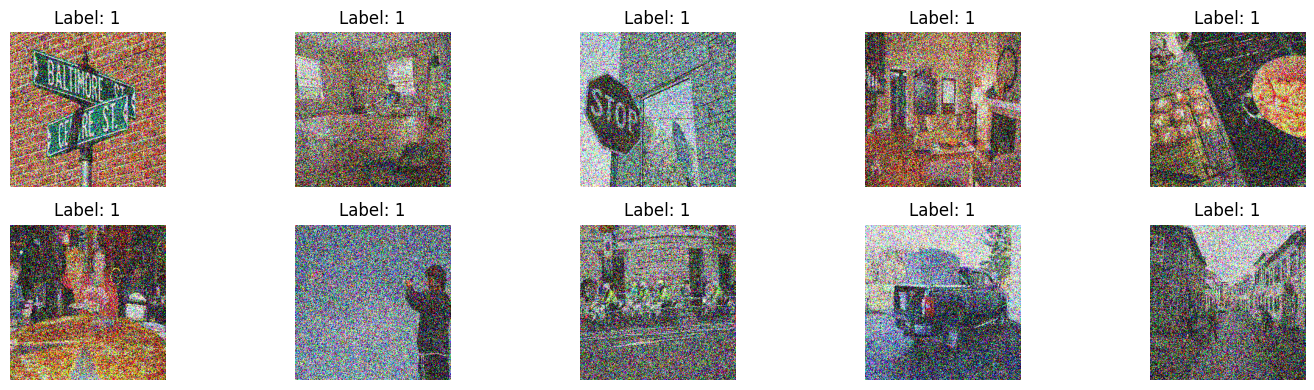

In [11]:
from src.utils import show_batch_images

show_batch_images(noisy_train_ds)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 256)            │     8,388,864 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,631,104 (32.93 MB)

 Trainable params: 8,630,400 (32.92 MB)

 Non-trainable params: 704 (2.75 KB)

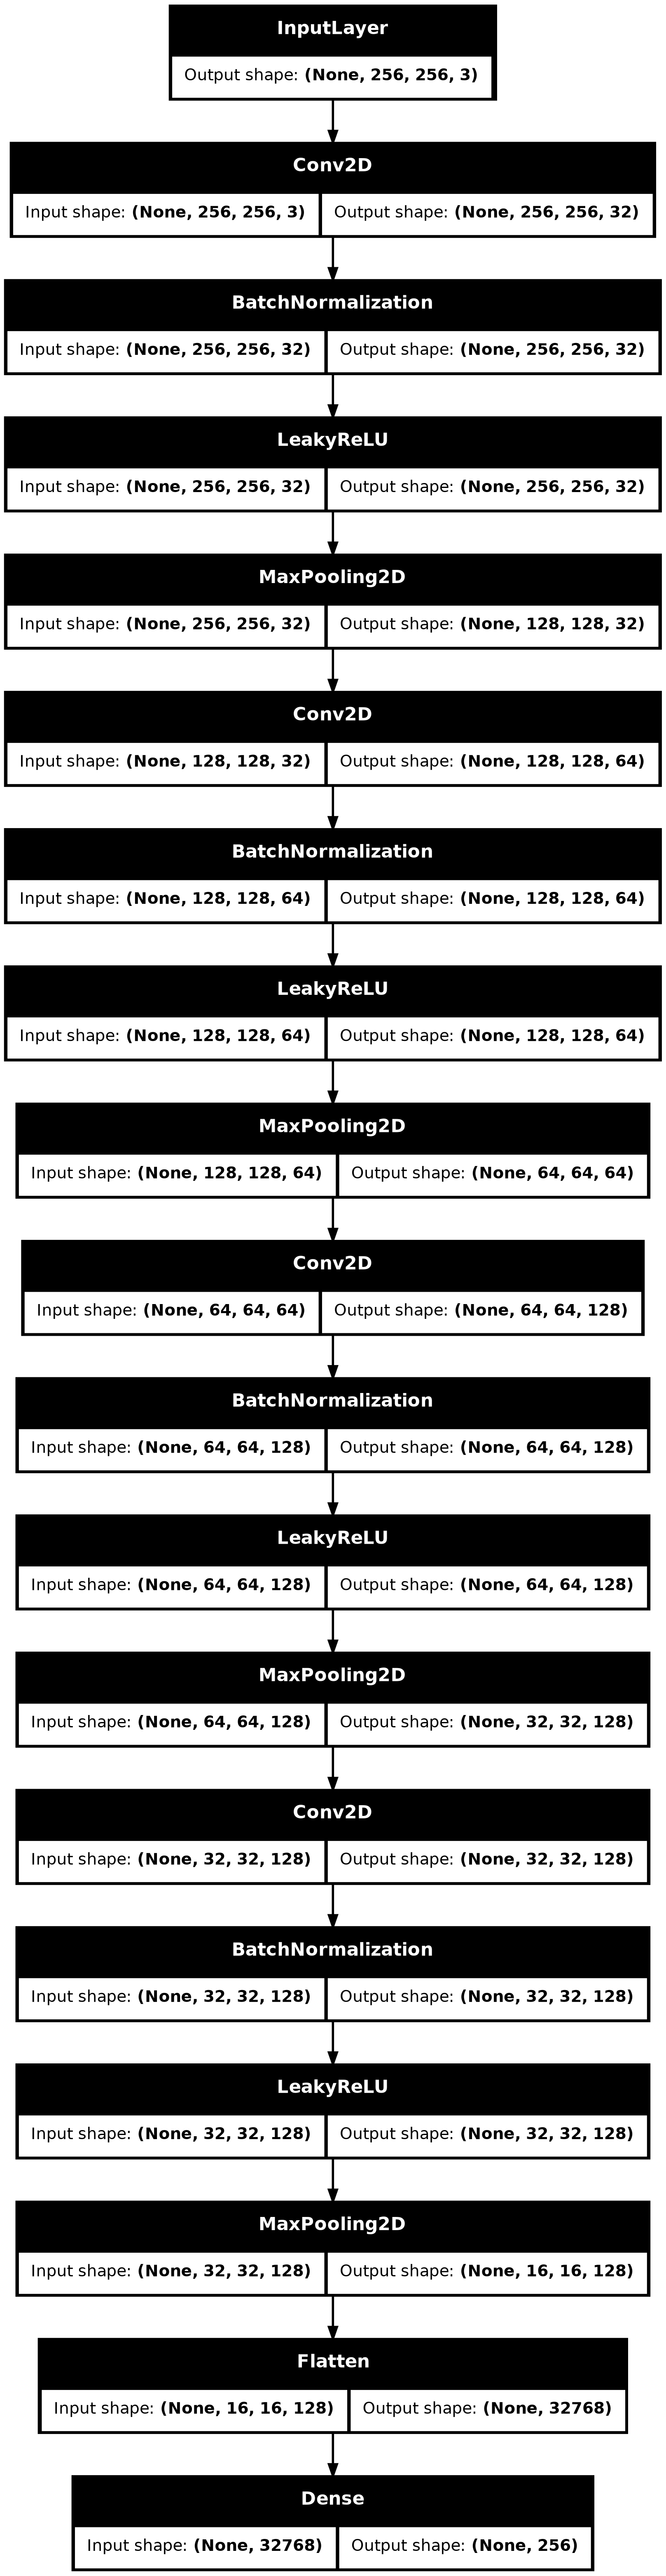

In [ ]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, BatchNormalization, LeakyReLU


latent_space_dim = 256

encoder_inputs = Input(shape=(256, 256, 3))
x = Conv2D(32, (3, 3), padding='same')(encoder_inputs)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (128, 128, 32)

x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (64, 64, 64)

x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (32, 32, 128)

x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # (16, 16, 128)

x = Flatten()(x)  # 16*16*128 = 32,768
latent_space = Dense(latent_space_dim, activation='relu', name="latent_space")(x)

encoder = Model(encoder_inputs, latent_space, name="encoder")
encoder.summary()

from keras.utils import plot_model
plot_model(encoder, to_file='encodersimple.png', show_shapes=True)



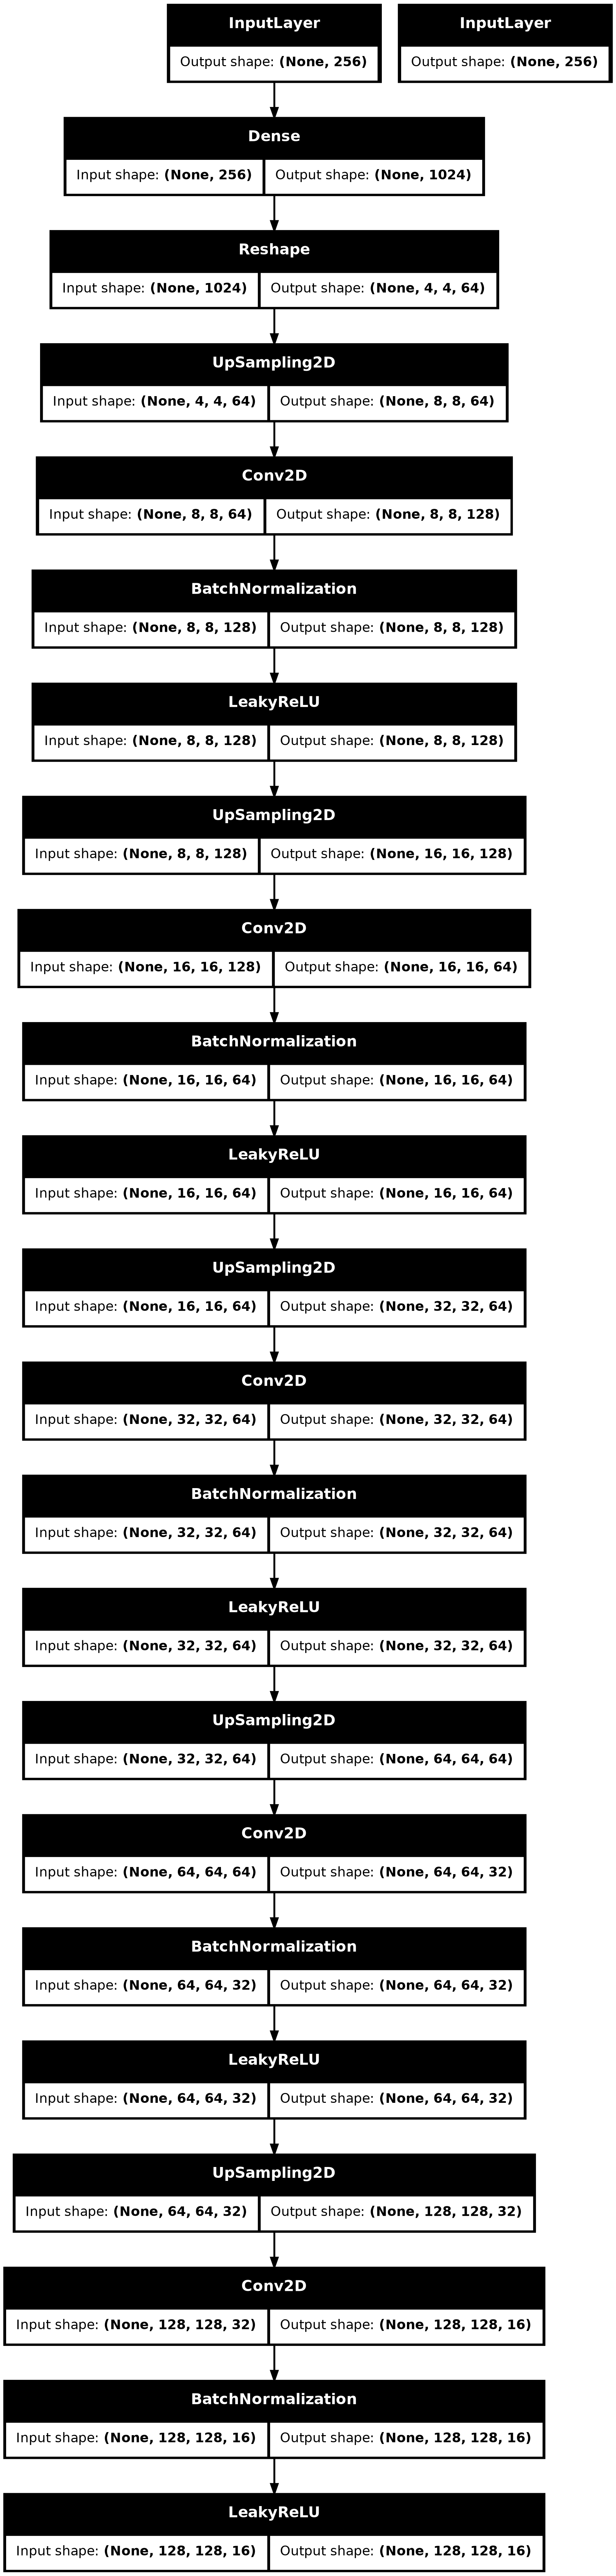

In [65]:
# Decoding #

# DeConv1
decoder_inputs = Input(shape=(latent_space_dim,))  

x = Dense(4 * 4 * 64, activation='relu')(decoder_inputs)
x = Reshape((4, 4, 64))(x) 

x = UpSampling2D((2, 2))(x)  # (16, 16)
x = Conv2D(128, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (32, 32)
x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (64, 64)
x = Conv2D(64, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (128, 128)
x = Conv2D(32, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (256, 256)
x = Conv2D(16, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

x = UpSampling2D((2, 2))(x)  # (256, 256)
x = Conv2D(8, (3, 3), padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU()(x)


decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")

from keras.utils import plot_model
plot_model(decoder, to_file='decodersimple.png', show_shapes=True)


In [66]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1024)      │    263,168 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 4, 4, 64)  │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_19    │ (None, 8, 8, 64)  │          0 │ reshape_4[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 8, 8, 128) │     73,856 │ up_sampling2d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 128) │        512 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 8, 128) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_20    │ (None, 16, 16,    │          0 │ leaky_re_lu_4[0]… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 16, 16,    │     73,792 │ up_sampling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_21    │ (None, 32, 32,    │          0 │ leaky_re_lu_5[0]… │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 32, 32,    │     36,928 │ up_sampling2d_21… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_44[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_22    │ (None, 64, 64,    │          0 │ leaky_re_lu_6[0]… │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 64, 64,    │     18,464 │ up_sampling2d_22… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_45[0][0] 

 Total params: 472,048 (1.80 MB)

 Trainable params: 471,440 (1.80 MB)

 Non-trainable params: 608 (2.38 KB)

In [45]:
from tensorflow.keras.models import Model


outputs = decoder(latent_space)
autoencoder = keras.Model(encoder_inputs,outputs, nmae="autoencoder")

autoencoder.compile(optimizer="adam"
                      , loss="binary_crossentropy"
                      , metrics=["accuracy"])


In [46]:
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [47]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

Cause: could not parse the source code of <function make_autoencoder_dataset.<locals>.<lambda> at 0x7f8a982bde40>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x, y: x

Match 1:
lambda x, y: x

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function make_autoencoder_dataset.<locals>.<lambda> at 0x7f8a982bde40>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x, y: x

Match 1:
lambda x, y: x

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function make_autoencoder_dataset.<locals>.<lambda> at 0x7f8a98377380>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x, y: x

Match 1:
lambda x, y: x

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function make_autoencoder_dataset.<locals>.<lambda> at 0x7f8a98377380>: found multiple definitions with identical signatures at the location. This error may be avoided by defining each lambda on a single line and with unique argument names. The matching definitions were:
Match 0:
lambda x, y: x

Match 1:
lambda x, y: x

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function make_autoencoder_dataset.<loca

In [ ]:
# Train the model
history = autoencoder.fit(train_autoenc_ds,
                epochs=20,
                batch_size= 32,
                shuffle= True,
                validation_data=val_autoenc_ds,
               )

Epoch 1/20


2025-04-15 11:43:24.616444: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-04-15 11:43:39.635961: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1215', 32 bytes spill stores, 32 bytes spill loads

2025-04-15 11:43:39.662767: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1215', 32 bytes spill stores, 32 bytes spill loads

2025-04-15 11:43:39.734211: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_f

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.3320 - loss: 0.6637

2025-04-15 11:44:17.779848: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1215', 28 bytes spill stores, 32 bytes spill loads

2025-04-15 11:44:17.895587: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1215', 32 bytes spill stores, 32 bytes spill loads

2025-04-15 11:44:17.906245: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1215', 32 bytes spill stores, 32 bytes spill loads



200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 268ms/step - accuracy: 0.3326 - loss: 0.6634 - val_accuracy: 0.4387 - val_loss: 0.6034
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 152ms/step - accuracy: 0.4616 - loss: 0.5992 - val_accuracy: 0.4625 - val_loss: 0.5925
Epoch 3/20
199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4775 - loss: 0.5908

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.4970 - loss: 0.5763 - val_accuracy: 0.4939 - val_loss: 0.5805
Epoch 18/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 34s 169ms/step - accuracy: 0.4971 - loss: 0.5768 - val_accuracy: 0.4920 - val_loss: 0.5784
Epoch 19/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.4967 - loss: 0.5767 - val_accuracy: 0.4955 - val_loss: 0.5813
Epoch 20/20
  2/200 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.4875 - loss: 0.5912  

2025-04-15 11:52:55.790076: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-04-15 11:52:55.790614: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4967 - loss: 0.5767

2025-04-15 11:53:16.025830: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.4966 - loss: 0.5767 - val_accuracy: 0.4951 - val_loss: 0.5798


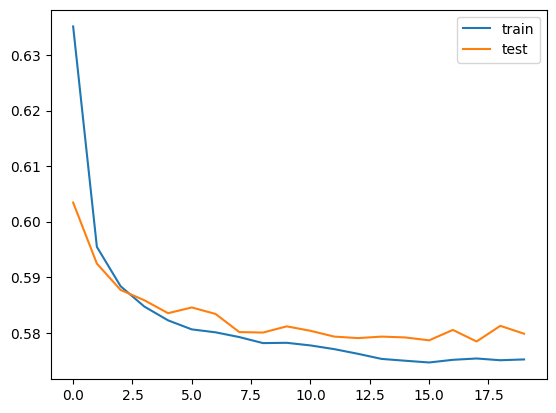

In [49]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


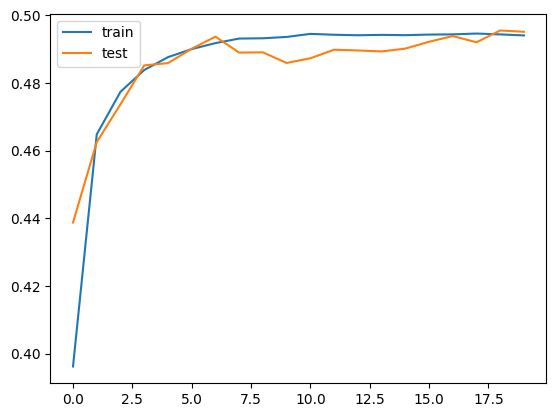

In [50]:

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()

In [51]:
def show_original_vs_decoded(dataset, model, n=10):
    for images, _ in dataset.take(4):  # Prend 1 batch
        decoded_images = model.predict(images)

        plt.figure(figsize=(15, 4))
        for i in range(n):
            # Image d'entrée
            ax = plt.subplot(2, n, i + 1)
            plt.imshow(images[i].numpy())
            plt.title("Original")
            plt.axis("off")

            # Image décodée
            ax = plt.subplot(2, n, n + i + 1)
            plt.imshow(decoded_images[i])
            plt.title("Reconstruit")
            plt.axis("off")
        plt.tight_layout()
        plt.show()
        break  # une seule fois

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


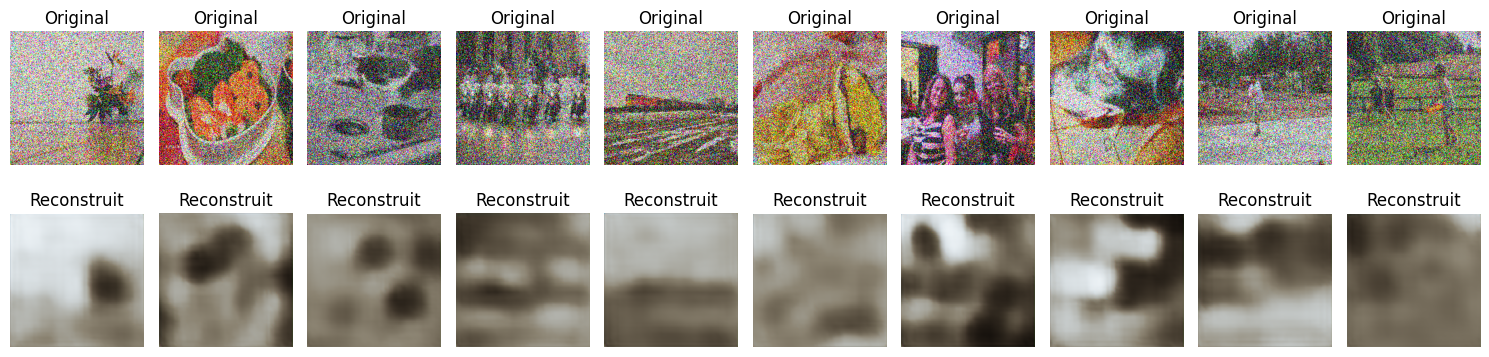

In [52]:
show_original_vs_decoded(noisy_val_ds, autoencoder)